In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, balanced_accuracy_score


# ── 1. Load data ─────────────────────────────────────────────────
df_bind = pd.read_excel('../data/single_metal_atoms_on_graphene_binding_energy_and_diffusion_barrier.xlsx')
df_bind_g = df_bind.groupby('Metal')[['Binding', 'Diffusion']].mean().reset_index()

df_aff = pd.read_excel("../data/supported_metal_M_oxygen_affinity_QMO_and_support_metal_affinity_QMM_prime.xlsx")
df_aff = df_aff.rename(columns={df_aff.columns[1]: 'QMO'})

df_nps = pd.read_excel('./NPs.xlsx')
df_nps = df_nps.rename(columns={'反应后MOF表面是否有纳米粒子': 'ExternalNP'})
df_nps['MOF'] = df_nps['MOF'].ffill()

# Define your renaming dictionary
mof_rename_dict = {
}

# Apply the replacement
df_nps["MOF"] = df_nps["MOF"].replace(mof_rename_dict)

df_mof = pd.read_csv('../data/MOF_factor.csv').reset_index(drop = True)
# Optional: check for consistency with df_mof
for i in df_nps["MOF"]:
    assert i in list(df_mof["MOF"]), f"{i} not in df_mof"
# ── 2. Merge all descriptors ─────────────────────────────────────
df = (
    df_nps
    .merge(df_mof, on='MOF', how='left')
    .merge(df_bind_g.rename(columns={'Binding': 'BindingEnergy', 'Diffusion': 'DiffusionBarrier'}),
           left_on='M', right_on='Metal', how='left')
    .merge(df_aff[['Metal', 'QMO']], left_on='M', right_on='Metal', how='left')
    .drop(columns=['Metal', 'Metal_aff'], errors='ignore')
)

df = df.dropna(subset=['BindingEnergy', 'DiffusionBarrier', 'QMO'])
df = df.drop(columns=['Metal_x', 'Metal_y'], errors='ignore')

noble_set = {'Au', 'Ag', 'Pt', 'Pd', 'Ir', 'Rh', 'Ru'}
df['Noble'] = df['M'].apply(lambda x: 1 if x in noble_set else 0)

core_feats = ['BindingEnergy','DiffusionBarrier','QMO','Noble']
extra_feats = [f"Factor{i}" for i in range(1, 46)]

features_all = core_feats + extra_feats

# Drop rows with missing values
df = df.dropna(subset=features_all + ['ExternalNP'])

X = df[features_all].copy()
y = df['ExternalNP'].astype(int).copy()

# ── 2. Train & evaluate logistic ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state = 42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")


# ── 2. Train & evaluate MLP (8-4) ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=100000, random_state=42, tol = 1e-6, activation="tanh"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=100000, random_state=42, tol = 1e-6, activation="tanh"))
])
# Re-fit on full dataset
pipeline.fit(X, y)

5-fold Accuracy: 0.818 ± 0.081
5-fold Balanced Accuracy: 0.817 ± 0.076
5-fold Accuracy: 0.782 ± 0.067
5-fold Balanced Accuracy: 0.776 ± 0.070


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(10, 4),
                               max_iter=100000, random_state=42, tol=1e-06))])

In [2]:
# --- core and candidate feature sets ---
core_feats = ['DiffusionBarrier','QMO','Noble']
extra_feats = [f"Factor{i}" for i in range(37, 38)]

In [3]:
features_all = core_feats + extra_feats

# Drop rows with missing values
df = df.dropna(subset=features_all + ['ExternalNP'])

X = df[features_all].copy()
y = df['ExternalNP'].astype(int).copy()

# ── 2. Train & evaluate logistic ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state = 42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")


# ── 2. Train & evaluate MLP (8-4) ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=100000, random_state=42, tol = 1e-6, activation="tanh"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")

5-fold Accuracy: 0.836 ± 0.079
5-fold Balanced Accuracy: 0.833 ± 0.078
5-fold Accuracy: 0.873 ± 0.045
5-fold Balanced Accuracy: 0.869 ± 0.045


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    make_scorer
)

# ── 1. Data ────────────────────────────────────────────────────────────────
features_all = core_feats + extra_feats
df = df.dropna(subset=features_all + ['ExternalNP'])

X = df[features_all].copy()
y = df['ExternalNP'].astype(int).copy()

# ── 2. Define MLP pipeline ────────────────────────────────────────────────
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(10, 4),
        max_iter=100000,
        random_state=42,
        tol=1e-6,
        activation="tanh"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 3. Cross-validated scalar metrics ─────────────────────────────────────
acc_scores = cross_val_score(
    mlp_pipeline, X, y, cv=cv, scoring='accuracy'
)

bal_acc_scores = cross_val_score(
    mlp_pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

auc_scores = cross_val_score(
    mlp_pipeline, X, y, cv=cv, scoring='roc_auc'
)

print(f"5-fold Accuracy:           {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy:  {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")
print(f"5-fold ROC-AUC:            {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

# ── 4. Out-of-fold predictions for visualization ──────────────────────────
# predicted class labels
y_pred_oof = cross_val_predict(
    mlp_pipeline, X, y, cv=cv, method='predict'
)

# predicted probabilities for positive class
y_prob_oof = cross_val_predict(
    mlp_pipeline, X, y, cv=cv, method='predict_proba'
)[:, 1]

# overall OOF metrics
acc_oof = accuracy_score(y, y_pred_oof)
bal_acc_oof = balanced_accuracy_score(y, y_pred_oof)
auc_oof = roc_auc_score(y, y_prob_oof)

print("\nOut-of-fold pooled metrics:")
print(f"Accuracy:          {acc_oof:.3f}")
print(f"Balanced Accuracy: {bal_acc_oof:.3f}")
print(f"ROC-AUC:           {auc_oof:.3f}")

5-fold Accuracy:           0.873 ± 0.045
5-fold Balanced Accuracy:  0.869 ± 0.045
5-fold ROC-AUC:            0.946 ± 0.060

Out-of-fold pooled metrics:
Accuracy:          0.873
Balanced Accuracy: 0.870
ROC-AUC:           0.965


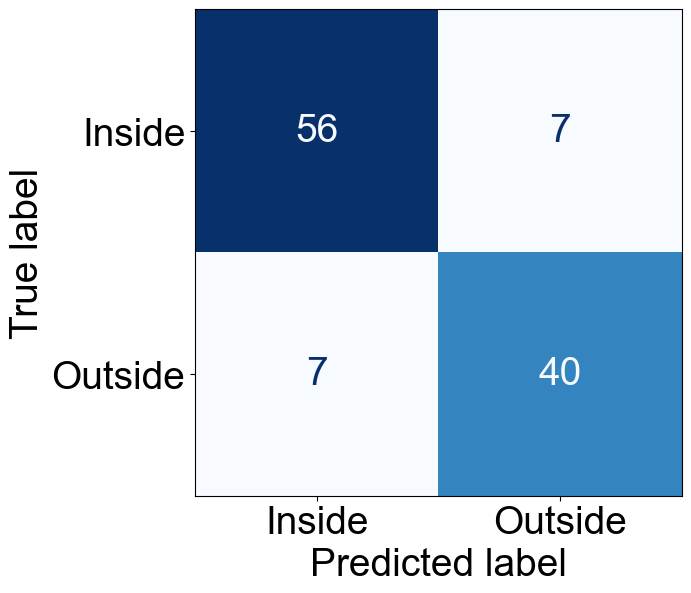

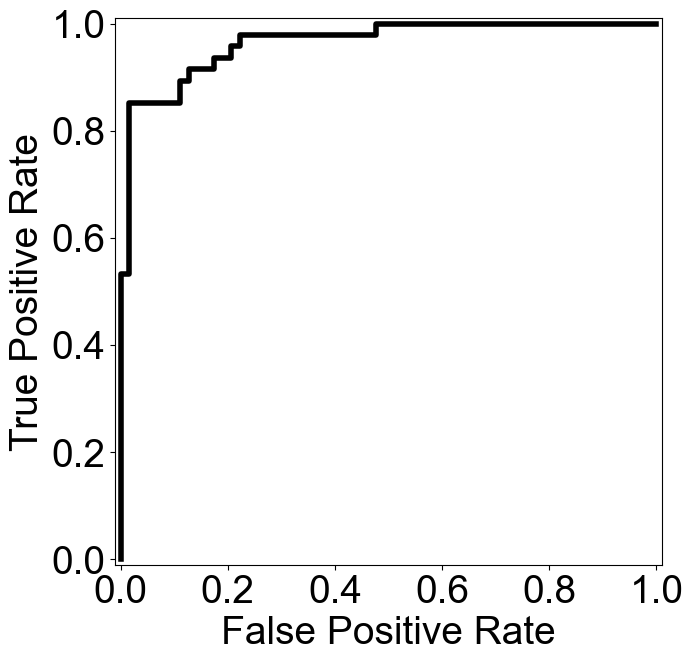

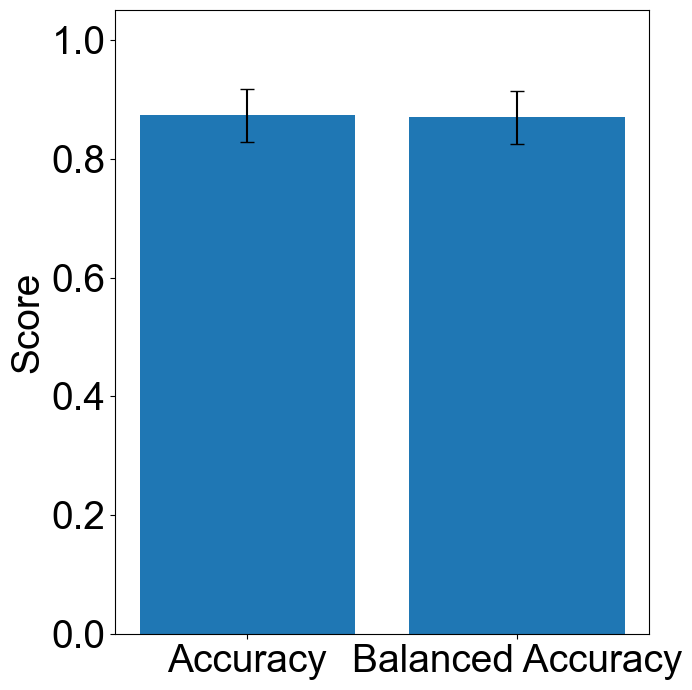

In [5]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# global font
rcParams["font.family"] = "Arial"

# helper: force all text in an axis to Arial
def force_arial(ax, ticksize=11, labelsize=12, textsize=12, legendsize=11):
    # axis labels
    ax.xaxis.label.set_fontname("Arial")
    ax.yaxis.label.set_fontname("Arial")
    ax.xaxis.label.set_fontsize(labelsize)
    ax.yaxis.label.set_fontsize(labelsize)

    # tick labels
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
        tick.set_fontsize(ticksize)

    # all text objects inside axes
    for txt in ax.texts:
        txt.set_fontname("Arial")
        txt.set_fontsize(textsize)

    # title if present
    ax.title.set_fontname("Arial")
    ax.title.set_fontsize(labelsize)

    # legend if present
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontname("Arial")
            text.set_fontsize(legendsize)
        if leg.get_title() is not None:
            leg.get_title().set_fontname("Arial")
            leg.get_title().set_fontsize(legendsize)

# ── 5. Confusion matrix ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
cm = confusion_matrix(y, y_pred_oof)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Inside", "Outside"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

force_arial(ax, ticksize=28, labelsize=28, textsize=28, legendsize=28)

plt.tight_layout()
plt.show()


# ── 6. ROC curve ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

roc_disp = RocCurveDisplay.from_predictions(y, y_prob_oof, ax=ax)
roc_disp.line_.set_linewidth(4)
roc_disp.line_.set_color("black")

leg = ax.get_legend()
if leg is not None:
    leg.remove()

force_arial(ax, ticksize=28, labelsize=28, textsize=28, legendsize=28)
ax.set_ylabel("True Positive Rate", fontname="Arial", fontsize=28)
ax.set_xlabel("False Positive Rate", fontname="Arial", fontsize=28)
plt.tight_layout()
plt.show()


# ── 7. Bar plot of CV metrics ─────────────────────────────────────────────
metric_names = ["Accuracy", "Balanced Accuracy"]
metric_means = [acc_scores.mean(), bal_acc_scores.mean()]
metric_stds  = [acc_scores.std(),  bal_acc_scores.std()]

fig, ax = plt.subplots(figsize=(7, 7))
ax.bar(metric_names, metric_means, yerr=metric_stds, capsize=5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")

force_arial(ax, ticksize=28, labelsize=28, textsize=28, legendsize=28)

plt.tight_layout()
plt.show()